In [23]:
import sys
from pathlib import Path

import pandas as pd

# Add project root to sys.path so absolute imports work
sys.path.insert(0, str(Path.cwd().parent.parent))

from configs import VOLLEYBALL_DETECTION_DIR, VOLLEYBALL_TRACKING_DIR


In [25]:

def load_action_detections(directory:Path):
    rows = [ ]
    for dir in directory.iterdir() :

        for folder in dir.iterdir() :

            path = directory/dir/folder/"action_detections.txt"

            with path.open( mode = "r") as f:
                for line in f:
                    p = line.strip().split("\t")
                    img, num = p[0], int(p[1])
                    # Flatten every person into their own row
                    for i in range(num):
                        start = 2 + (i * 6)
                        rows.append({
                            "image": img,
                            "x": int(p[start]),
                            "y": int(p[start+1]),
                            "w": int(p[start+2]),
                            "h": int(p[start+3]),
                            "score": float(p[start+4]),
                            "action": p[start+5],
                        })

    df = pd.DataFrame(rows)
    return df

df = load_action_detections(VOLLEYBALL_DETECTION_DIR)


In [28]:
df.head()

,image,x,y,w,h,score,action
0,19440.jpg,876,472,58,101,0.952111,moving
1,19440.jpg,266,425,59,94,0.997718,standing
2,19440.jpg,494,462,46,94,0.996035,standing
3,19440.jpg,910,402,38,94,0.993717,standing
4,19440.jpg,568,371,31,84,0.991664,standing


In [29]:
print("each category count")
df["action"].value_counts()

each category count


action
standing    1488340
moving       165985
waiting       99646
blocking      42902
falling       40583
digging       39110
spiking       20498
setting       18028
jumping        2527
Name: count, dtype: int64

<Axes: xlabel='action'>

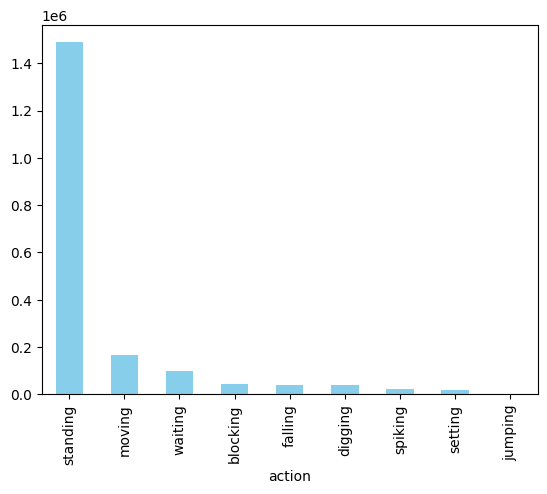

In [32]:
df["action"].value_counts().plot(kind="bar", color="skyblue")

In [37]:
def load_tracking_annotations(directory:Path):
    all_dfs = [ ]
    for dir in directory.iterdir():
        if dir.is_dir():
            for folder in dir.iterdir():
                path = directory/dir/folder/f"{folder.stem}.txt"
                df_track = pd.read_csv(path,
                                    sep=r"\s+",
                                    header=None,
                                    names=["id", "x1", "y1", "x2", "y2", "frame", "lost", "group", "status", "action"])
                all_dfs.append(df_track)
    # Check the first few rows
    # print(df_track.head())
    big_df = pd.concat(all_dfs, ignore_index=True)
    return big_df



<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3270494/2809341741.py:8: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


In [38]:

tracking_df = load_tracking_annotations(VOLLEYBALL_TRACKING_DIR)

In [39]:
tracking_df.head()

,id,x1,y1,x2,y2,frame,lost,group,status,action
0,0,288,510,384,651,39545,0,1,0,standing
1,0,281,510,374,651,39546,0,1,1,standing
2,0,274,511,365,651,39547,0,1,1,standing
3,0,268,511,355,652,39548,0,1,1,standing
4,0,261,512,346,652,39549,0,1,1,standing


<Axes: xlabel='action'>

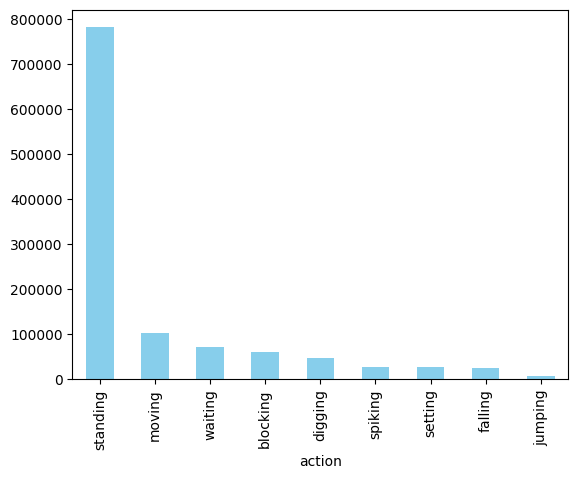

In [40]:
tracking_df["action"].value_counts().plot(kind="bar", color="skyblue")

In [43]:
df = tracking_df.groupby("frame").agg(list)
df.head()

,id,x1,y1,x2,y2,lost,group,status,action
frame,,,,,,,,,
965,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[955, 903, 806, 556, 573, 591, 316, 317, 319, ...","[297, 384, 486, 358, 320, 278, 424, 383, 359, ...","[987, 953, 849, 602, 621, 628, 358, 356, 358, ...","[378, 511, 635, 489, 421, 385, 561, 489, 473, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[digging, digging, standing, standing, standin..."
966,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[957, 902, 804, 553, 575, 589, 315, 317, 319, ...","[290, 385, 487, 358, 323, 279, 425, 383, 360, ...","[990, 952, 848, 600, 623, 626, 358, 356, 358, ...","[375, 513, 635, 488, 425, 386, 562, 490, 474, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[digging, standing, standing, standing, standi..."
967,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[959, 901, 802, 551, 577, 587, 315, 317, 319, ...","[283, 387, 488, 358, 326, 280, 426, 383, 361, ...","[993, 951, 848, 598, 625, 624, 358, 356, 358, ...","[373, 515, 635, 487, 429, 387, 564, 492, 475, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[digging, standing, standing, standing, standi..."
968,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[961, 900, 801, 549, 579, 585, 315, 317, 319, ...","[276, 389, 489, 358, 330, 281, 428, 383, 362, ...","[996, 950, 848, 596, 627, 622, 358, 356, 358, ...","[371, 518, 636, 487, 433, 388, 566, 494, 476, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1]","[digging, standing, standing, standing, standi..."
969,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[963, 898, 799, 544, 581, 582, 315, 317, 319, ...","[270, 390, 490, 359, 330, 284, 429, 383, 363, ...","[999, 949, 848, 595, 628, 623, 358, 356, 358, ...","[369, 517, 636, 488, 433, 388, 567, 496, 477, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[digging, standing, standing, standing, standi..."
